In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [3]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [4]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [5]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [6]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [7]:
indices_array = np.array(indices)
incomplete_file_ind = [5, 18, 26, 29]

In [8]:
for ind in incomplete_file_ind:
    sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[ind], top100['end_UTC'].iloc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    sci_query

    sci_files = Fido.fetch(sci_query)
    sci_files = sorted(sci_files)
    
    
    sci_data_A = Product(sci_files[0])
    sci_data_B = Product(sci_files[1])
    
    df_A = get_stix_df(sci_data_A, energy_ranges)
    df_B = get_stix_df(sci_data_B, energy_ranges)
    
    combined_df = pd.concat([df_A, df_B])
    
    combined_df = combined_df.sort_index()
    
    df = combined_df[~combined_df.index.duplicated(keep="first")]

    df_list[ind]=df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [9]:
exclude = [26, 33, 35, 36, 55, 56, 58, 59, 61, 66, 70, 73, 77, 80, 83, 90, 96]

In [10]:
df_list_refined = df_list.copy()
for ind in indices:
    if ind in exclude:
        df_list_refined[ind]='excluded'

indices_refined = list(set(indices)-set(top100.index[exclude]))

In [11]:
df_list_filtered = []
for loc, ind in enumerate(indices):
    if ind in indices_refined:
        df_filtered  = df_list[loc].copy()
        
        filtered_2550 = savgol_filter(df_list[loc]['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
        filtered_50100 = savgol_filter(df_list[loc]['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

        df_filtered['25.0 keV-50.0 keV'] = filtered_2550
        df_filtered['50.0 keV-100.0 keV'] = filtered_50100

        df_list_filtered.append(df_filtered)
        
    if ind not in indices_refined:
        df_list_filtered.append('excluded')
        

In [142]:
columns = ('flare_list_id', 'start_time', 'end_time','peak_time', 'peak_counts', 'number_of_peaks', 'rise_time', 'decay_time','start_time (50-100 keV)', 'end_time (50-100 keV)', 'peak_counts (50-100 keV)', 'rise_time (50-100 keV)', 'decay_time (50-100 keV)', 'comments')
data=np.zeros((len(indices_refined), len(columns)))


In [31]:
filtered_stats_df = pd.DataFrame(data, columns = columns)

In [32]:
filtered_stats_df['flare_list_id'] = filtered_stats_df['flare_list_id'].astype(int)
label = 0
for loc, ind in enumerate(indices):
    if loc not in exclude:
        filtered_stats_df.loc[label, 'flare_list_id'] = int(ind)
        label+=1

In [37]:
filtered_stats_df['start_time'] = filtered_stats_df['start_time'].astype(str)
filtered_stats_df['end_time'] = filtered_stats_df['end_time'].astype(str)
filtered_stats_df['rise_time'] = filtered_stats_df['rise_time'].astype(str)
filtered_stats_df['decay_time'] = filtered_stats_df['decay_time'].astype(str)
filtered_stats_df['peak_time'] = filtered_stats_df['peak_time'].astype(str)
filtered_stats_df['start_time (50-100 keV)'] = filtered_stats_df['start_time (50-100 keV)'].astype(str)
filtered_stats_df['end_time (50-100 keV)'] = filtered_stats_df['end_time (50-100 keV)'].astype(str)
filtered_stats_df['rise_time (50-100 keV)'] = filtered_stats_df['rise_time (50-100 keV)'].astype(str)
filtered_stats_df['decay_time (50-100 keV)'] = filtered_stats_df['decay_time (50-100 keV)'].astype(str)

In [143]:
label=0
i=0
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        
        r = top100['solo_position_AU_distance'].loc[ind]

        peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
        peak_counts_scaled = peak_counts/r**2
        filtered_stats_df.loc[label, 'peak_counts'] = peak_counts_scaled
        peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
        filtered_stats_df.loc[label, 'peak_time'] = str(peak_loc)

        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = plot_df[(plot_df['25.0 keV-50.0 keV']<10/r**2) & (plot_df.index>peak_loc)].index[0]

        filtered_stats_df.loc[label, 'start_time'] = str(tstart)
        filtered_stats_df.loc[label, 'end_time'] = str(tend)
        
        plot_df = plot_df.truncate(t(tstart), t(tend))

        rise_time = peak_loc - tstart
        decay_time = tend - peak_loc
        filtered_stats_df.loc[label, 'rise_time'] = str(rise_time).split(" ")[-1]
        filtered_stats_df.loc[label, 'decay_time'] = str(decay_time).split(" ")[-1]

        peak_counts_50_100 = np.max(plot_df['50.0 keV-100.0 keV'])
        peak_counts_50_100_scaled = peak_counts_50_100/r**2
        filtered_stats_df.loc[label, 'peak_counts (50-100 keV)'] = peak_counts_50_100_scaled
        peak_loc_50_100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] == peak_counts_50_100][0]

        flare_50_100 = plot_df[plot_df['50.0 keV-100.0 keV']>3/r**2]

        if flare_50_100.empty:
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'start_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'end_time (50-100 keV)'] = np.nan
        
        else:
            tstart_50_100 = flare_50_100.index[0]
            #tend_50_100 = flare_50_100.index[-1]
            # tend_50_100 = plot_df[(plot_df['50.0 keV-100.0 keV']<3/r**2) & (plot_df.index>peak_loc_50_100)]
            # if tend_50_100.empty:
            #     findend = plot_df[(plot_df.index>peak_loc_50_100)&(plot_df.index<t(tend))]
            #     tend_50_100 = findend.index[findend['50.0 keV-100.0 keV'] == np.min(findend['50.0 keV-100.0 keV'])][-1]
            # else:
                #tend_50_100 = tend_50_100.index[0]
            tend_50_100 = flare_50_100.index[-1]

            rise_time_50_100 = peak_loc_50_100 - tstart_50_100
            decay_time_50_100 = tend_50_100 - peak_loc_50_100
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = str(rise_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = str(decay_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'start_time (50-100 keV)'] = str(tstart_50_100)
            filtered_stats_df.loc[label, 'end_time (50-100 keV)'] = str(tend_50_100)

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        filtered_stats_df.loc[label, 'number_of_peaks'] = len(peaks)
        #peak_locs[label]=peaks

        label+=1
    i+=1

In [141]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted', label='10 counts/keV s (scaled)')
        plt.axhline(3/r**2, 0, 1, color='salmon', linestyle='dotted', label='3 counts/keV s (scaled)')

        if pd.notna(tend_50_100):
            plt.axvline(t(tend_50_100), 0, 1, color = 'pink', linestyle = 'dashed', label = 'Estimated Start/End (50-100 keV)')
            plt.axvline(t(tstart_50_100), 0, 1, color = 'pink', linestyle = 'dashed')

        rise_time_td = pd.to_timedelta(filtered_stats_df['rise_time'].iloc[i])
        decay_time_td = pd.to_timedelta(filtered_stats_df['decay_time'].iloc[i])
        
        duration = rise_time_td+decay_time_td
        duration = duration.total_seconds()
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(seconds=0.1*duration), t(tend)+dt.timedelta(seconds=0.1*duration))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered_cropped/top_100_flares_science_data_plot"+str(i)+"_filtered_cropped.png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15864\864043006.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [110]:
rise_time_td = pd.to_timedelta(filtered_stats_df['rise_time'])
decay_time_td = pd.to_timedelta(filtered_stats_df['decay_time'])

durations = rise_time_td+decay_time_td
durations = durations.dt.total_seconds()

In [82]:
np.where(np.array(durations)>2000)

(array([7]),)

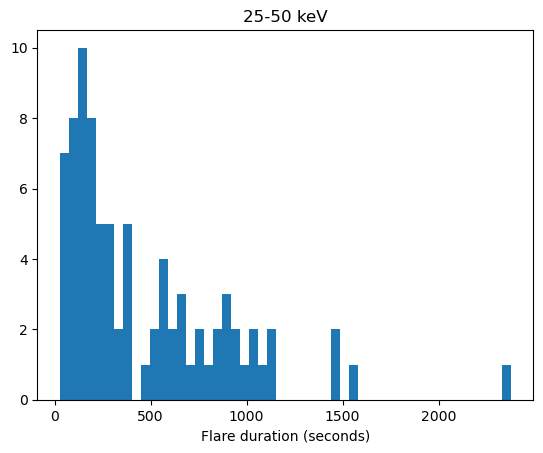

In [136]:
plt.hist(durations, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_hist_filtered.png", bbox_inches='tight')

In [84]:
rise_time_50_100_td = pd.to_timedelta(filtered_stats_df['rise_time (50-100 keV)'])
decay_time_50_100_td = pd.to_timedelta(filtered_stats_df['decay_time (50-100 keV)'])

durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
durations_50_100 = durations_50_100.dt.total_seconds()

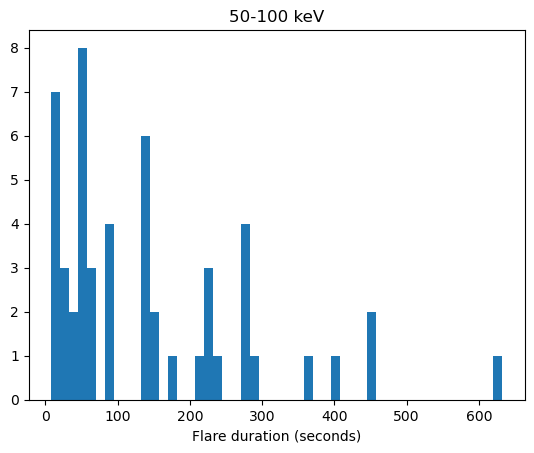

In [130]:
plt.hist(durations_50_100, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_hist_50_100_filtered.png", bbox_inches='tight')

Text(0.5, 0, 'Scaled peak counts')

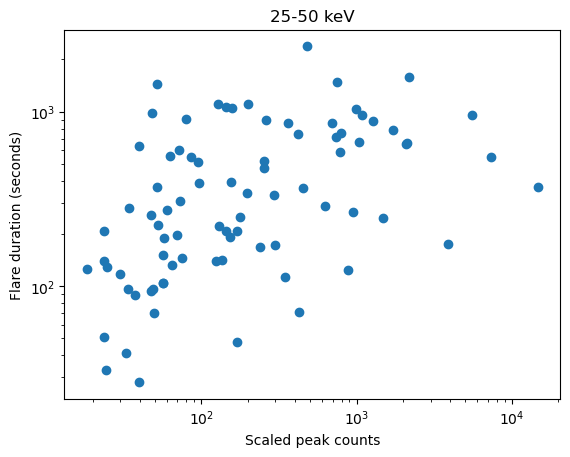

In [132]:
plt.scatter(filtered_stats_df['peak_counts'], durations)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.xlabel('Scaled peak counts')
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_counts_filtered.png", bbox_inches='tight')

Text(0.5, 0, 'Scaled peak counts')

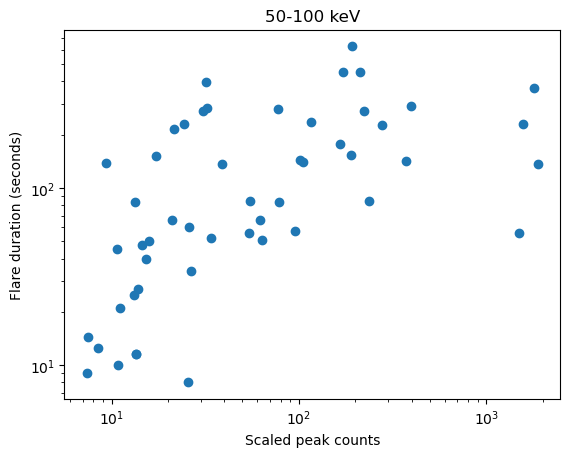

In [133]:
plt.scatter(filtered_stats_df['peak_counts (50-100 keV)'], durations_50_100)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.xlabel('Scaled peak counts')
#plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_counts_50_100_filtered.png", bbox_inches='tight')

Text(0.5, 0, 'Ratio of peaks (50-100 keV:25-50 keV)')

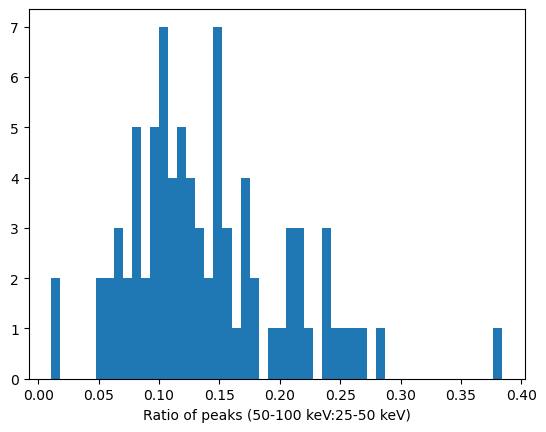

In [88]:
peak_ratios = filtered_stats_df['peak_counts (50-100 keV)']/filtered_stats_df['peak_counts']
plt.hist(peak_ratios, bins=50)
plt.xlabel('Ratio of peaks (50-100 keV:25-50 keV)')

In [75]:
rise_time_td

Timedelta('0 days 00:01:45')

(array([17., 25.,  9.,  6.,  6.,  1.,  3.,  2.,  1.,  0.,  3.,  4.,  0.,
         1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.05708013,  0.27800749,  0.49893486,  0.71986222,  0.94078958,
         1.16171695,  1.38264431,  1.60357167,  1.82449903,  2.0454264 ,
         2.26635376,  2.48728112,  2.70820849,  2.92913585,  3.15006321,
         3.37099057,  3.59191794,  3.8128453 ,  4.03377266,  4.25470003,
         4.47562739,  4.69655475,  4.91748212,  5.13840948,  5.35933684,
         5.5802642 ,  5.80119157,  6.02211893,  6.24304629,  6.46397366,
         6.68490102,  6.90582838,  7.12675574,  7.34768311,  7.56861047,
         7.78953783,  8.0104652 ,  8.23139256,  8.45231992,  8.67324728,
         8.89417465,  9.11510201,  9.33602937,  9.55695674,  9.7778841 ,
         9.99881146, 10.21973882, 10.44066619, 10.66159355,

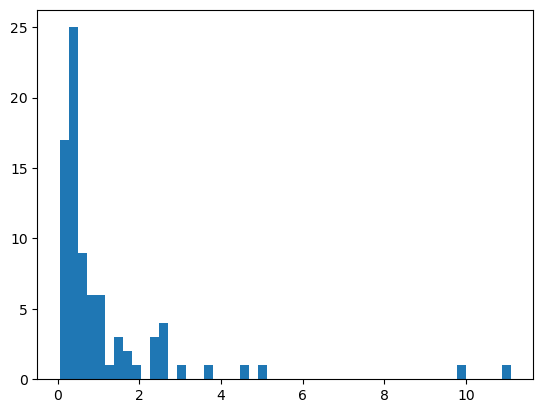

In [96]:
rise_time_s = rise_time_td.dt.total_seconds()
decay_time_s = decay_time_td.dt.total_seconds()

rise_decay_ratio = rise_time_s/decay_time_s

rise_time_s_50100 = rise_time_50_100_td.dt.total_seconds()
decay_time_s_50100 = decay_time_50_100_td.dt.total_seconds()

rise_decay_ratio_50100 = rise_time_s_50100/decay_time_s_50100

plt.hist(rise_decay_ratio, bins=50)

(array([6., 6., 6., 6., 6., 5., 1., 4., 1., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 2., 0., 0., 0., 0., 1., 1.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.10218978, 0.2455306 , 0.38887142, 0.53221224, 0.67555306,
        0.81889388, 0.9622347 , 1.10557552, 1.24891634, 1.39225716,
        1.53559798, 1.6789388 , 1.82227962, 1.96562044, 2.10896126,
        2.25230208, 2.3956429 , 2.53898372, 2.68232454, 2.82566536,
        2.96900618, 3.112347  , 3.25568782, 3.39902864, 3.54236946,
        3.68571028, 3.82905109, 3.97239191, 4.11573273, 4.25907355,
        4.40241437, 4.54575519, 4.68909601, 4.83243683, 4.97577765,
        5.11911847, 5.26245929, 5.40580011, 5.54914093, 5.69248175,
        5.83582257, 5.97916339, 6.12250421, 6.26584503, 6.40918585,
        6.55252667, 6.69586749, 6.83920831, 6.98254913, 7.12588995,
        7.26923077]),
 <BarContainer object of 50 artists>)

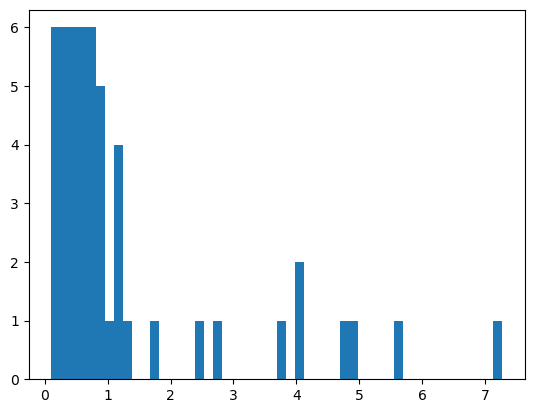

In [92]:
plt.hist(rise_decay_ratio_50100, bins=50)

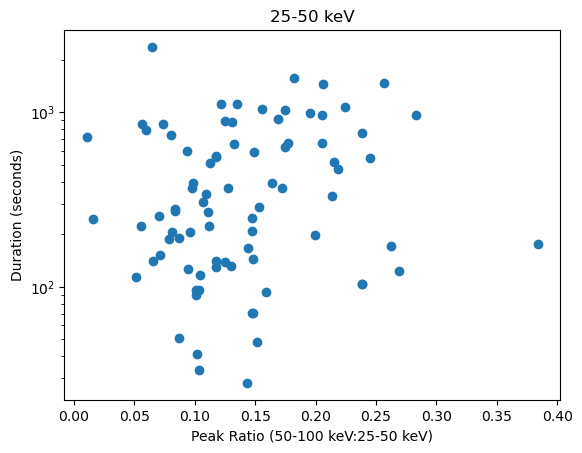

In [134]:
plt.scatter(peak_ratios, durations)
plt.yscale('log')
plt.xlabel('Peak Ratio (50-100 keV:25-50 keV)')
plt.ylabel('Duration (seconds)')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_ratio.png", bbox_inches='tight')

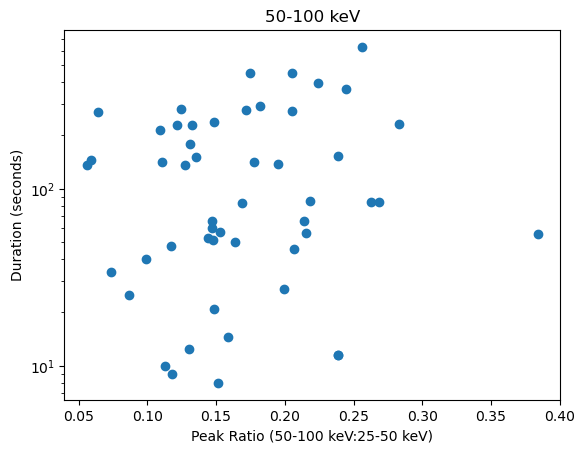

In [138]:
plt.scatter(peak_ratios, durations_50_100)
plt.yscale('log')
plt.xlabel('Peak Ratio (50-100 keV:25-50 keV)')
plt.ylabel('Duration (seconds)')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_ratio_50_100.png", bbox_inches='tight')

In [137]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted', label='10 counts/keV s (scaled)')
        plt.axhline(3/r**2, 0, 1, color='salmon', linestyle='dotted', label='3 counts/keV s (scaled)')

        if pd.notna(tend_50_100):
            plt.axvline(t(tend_50_100), 0, 1, color = 'pink', linestyle = 'dashed', label = 'Estimated Start/End (50-100 keV)')
            plt.axvline(t(tstart_50_100), 0, 1, color = 'pink', linestyle = 'dashed')
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_flares_refined/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15864\2510669246.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [154]:
label=0
i=0
half_max_points = []
half_max_vals = []
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        tstart = filtered_stats_df['start_time'].iloc[label]
        tend = filtered_stats_df['end_time'].iloc[label]
        tpeak = filtered_stats_df['peak_time'].iloc[label]

        r = top100['solo_position_AU_distance'].loc[ind]
        max_counts = (filtered_stats_df['peak_counts'].iloc[label])*r**2

        plot_df = sci_df.truncate(t(tstart), t(tend))

        half_max = 0.5*max_counts
        half_max_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] >= half_max][0]
        half_max_points.append(half_max_loc)
        half_max_vals.append(half_max)

        label+=1
    i+=1

In [162]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

        ax.plot(t(half_max_points[i]), half_max_vals[i], marker='o', color='yellow')
        plt.axhline(half_max_vals[i], 0, 1, linestyle='dashed', color='yellow')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/fwhm_testing/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15864\1664480713.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [158]:
print(t(half_max_points[6]), half_max_vals[6])

2024-05-14 16:44:37.071000 1505.076892753621


In [163]:
df_list_filtered[0]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-07-22 21:25:24.318,6.325855,1.735114
2024-07-22 21:25:44.318,6.345750,1.725281
2024-07-22 21:26:04.318,6.364520,1.716378
2024-07-22 21:26:24.318,6.382166,1.708407
2024-07-22 21:26:44.318,6.398687,1.701366
...,...,...
2024-07-23 03:29:38.668,8.382306,5.107155
2024-07-23 03:29:43.318,8.358246,5.117677
2024-07-23 03:29:48.068,8.331464,5.129098
2024-07-23 03:29:52.768,8.301960,5.141419
